# Fexigo MNIST demo

This notebook contains the code to run a demo for using the model to make predictions and explain its decisions.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import keras
import pandas as pd
from keras import datasets
from sklearn.model_selection import train_test_split
import sklearn.linear_model as sklm
from sklearn.metrics import roc_curve, auc
import sklearn.metrics
from PIL import Image

Load data and model.

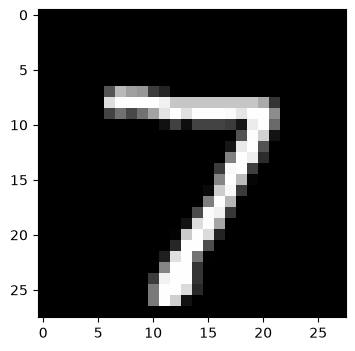

In [33]:
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

model = keras.models.load_model('models/mnist_cnn.keras')

plt.figure(figsize=(4, 4))
plt.imshow(X_test[0], cmap="gray")
plt.show()

Load image for prediction.

Note: You can edit the image to write your own number.

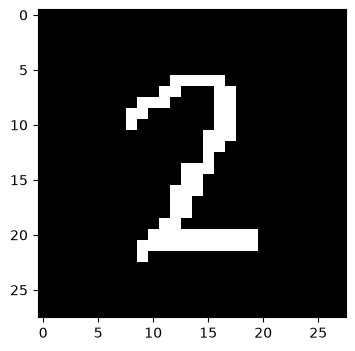

In [ ]:
# Load image
img = Image.open("number.bmp")

# Check image format and size
img = img.convert("L")
img = img.resize((28, 28))

# Convert to array and normalize
img_array = np.array(img, dtype=np.float32)
img_array /= 255.0
img_array = img_array.reshape(1, 28, 28, 1)

# Plot number
plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.show()

Apply the model to predict the image.

In [35]:
probs = model.predict(img_array, verbose=0)
pred = np.argmax(probs)
print("Predicción:", pred)
print("Probabilidades:", probs)

img_mnist = X_test[0].reshape(1, 28, 28, 1).astype("float32") 

probs = model.predict(img_mnist, verbose=0)
pred = np.argmax(probs)

print("Predicción:", pred)
print("Probabilidades:", probs[0])
print("Etiqueta real:", np.argmax(y_test[0]))

Predicción: 1
Probabilidades: [[0.10353813 0.10506205 0.09805772 0.09679104 0.10146879 0.1017165
  0.09320232 0.10194166 0.10102494 0.09719685]]
Predicción: 7
Probabilidades: [7.7380542e-15 1.3733345e-15 2.6818088e-09 2.4706814e-10 1.2486780e-20
 7.9192179e-18 2.4262140e-18 1.0000000e+00 2.7353092e-12 2.4141559e-11]
Etiqueta real: 7
